# Overlapping all the datasets

The core challenge of multi-omics integration is linking datasets that operate on completely different coordinate systems. For example, we might want to link the statistical fold-change of a gene (from RNA-seq) to the physical location of an open chromatin enhancer (from ATAC-seq).

## Learning objectives

- Load and explore genomic data using Bioconductor classes such as `GRangesList` and `RangedSummarizedExperiment`.
- Subset and filter genomic features based on annotation or genomic coordinates.
- Perform basic overlap and distance-based queries between genomic intervals.
- Integrate multi-assay data (e.g., chromatin marks and gene expression) using shared genomic coordinates.

## Initial setup and data loading

Before we begin calculating the genomic overlaps, we need to set up our environment by loading the necessary R packages, importing our processed data, and defining a custom helper function.

### Loading required libraries

In [1]:
suppressPackageStartupMessages(suppressWarnings({
  # Core/utility packages
  library(parallel)
  library(R.utils)

  # Bioconductor
  library(SummarizedExperiment)
  library(rtracklayer)
  library(gUtils)

  # Plotting/visualization
  library(ComplexHeatmap)
  library(EnrichedHeatmap)
  library(circlize)

  # Data wrangling/Tidyverse
  # (MASKING! Laod last so its verbs never get overwritten)
  library(data.table)
  library(dplyr)
  library(tibble)
}))

### Loading the SummarizedExperiment objects

In [2]:
atac <- readRDS("data/atac_se.rds")
rna <- readRDS("data/rna_se.rds")
h3k4me3 <- readRDS("data/h3k4me3_se.rds")
h3k4me1 <- readRDS("data/h3k4me1_se.rds")
h3k27me3 <- readRDS("data/h3k27me3_se.rds")
h3k27ac <- readRDS("data/h3k27ac_se.rds")

### Defining a custom function for multi-omics integration

Unfortunately, standard Bioconductor packages do not have a simple, built-in "left-join" function for genomic coordinates. To solve this, we define a custom helper function called `metaGR()`.

This function takes a primary, target set of genomic regions (`gr1`) and looks for any physical overlaps with a secondary set of regions (`gr2`). Wherever a physical overlap occurs, it extracts the statistical metadata columns (like `logFC` or `q-value`) from `gr2` and seamlessly attaches them as new columns to the overlapping region in `gr1`. If a region in `gr1` doesn't overlap with anything, it safely fills those new columns with `NA`.

> **Why a minimum overlap of 10?**
> By default, the R overlap engine registers a "hit" even if two genomic features only touch by a single base pair. Because sequencing data always has a tiny bit of mapping noise at the very edges of peaks, 1-bp or 2-bp overlaps are often accidental false positives. Setting the default minimum overlap to `10` base pairs (which is roughly one full turn of the DNA double helix) ensures that the physical overlap is robust and represents a genuine biological co-localization!

In [3]:
# Merges metadata from gr2 onto gr1 based on genomic overlaps
metaGR <- function(gr1, gr2, minOverlap = 10) {
  # 1. Save the original metadata from our primary target object (gr1)
  original_mcols <- mcols(gr1)

  # 2. Find where the two genomic objects physically overlap
  # gr1 is the "query", gr2 is the "subject"
  hits <- findOverlaps(
    query = gr1,
    subject = gr2,
    minoverlap = minOverlap)
  
  # Extract the row indices of the overlapping regions
  idx_gr1 <- queryHits(hits)    # Which regions in gr1 had a match?
  idx_gr2 <- subjectHits(hits)  # Which regions in gr2 did they match with?

  # 3. Create a blank metadata table to hold the incoming gr2 data
  # It must be the exact same length as gr1, filled with NAs (for non-overlaps)
  new_mcols <- DataFrame(
    matrix(NA, nrow = length(gr1), ncol = ncol(mcols(gr2))))
  colnames(new_mcols) <- colnames(mcols(gr2))
  
  # 4. Inject the gr2 metadata exactly into the rows where an overlap occurred
  new_mcols[idx_gr1, ] <- mcols(gr2)[idx_gr2, , drop = FALSE]

  # 5. Bind the original gr1 metadata and the newly acquired gr2 metadata together
  mcols(gr1) <- cbind(original_mcols, new_mcols)
  
  # Return the fully annotated primary object
  return(gr1)
}

## Constructing the multi-omics Overlap Matrix

We will systematically extract the genomic coordinates (`rowRanges`) from our ATAC, RNA, and ChIP-seq objects. Rather than trying to overlap the entire genome, we will apply a strict statistical filter to each dataset to isolate only the most highly significant, dynamic features (specifically requiring an **absolute** `logFC >= 0.5` and a `qvalue <= 0.1`). Furthermore, since this training course focuses strictly on Chromosomes 1 and 2, we will proactively filter our datasets by `seqnames` at this early stage to drastically reduce memory usage and computation time.

To prevent confusing naming collisions when we stitch these datasets together (since they all contain columns identically named "logFC" and "qvalue"), we will prepend a unique identifier prefix (like `ATAC_` or `RNA_`) to the metadata of each object. Finally, we will use our `metaGR()` function to project all of these significant RNA and ChIP-seq features directly onto our foundational ATAC-seq peaks, creating a single, unified Overlap Matrix.

### Processing and merging datasets

The values selected for the filtering is a very common **baseline heuristic**, but it is not a hard law. A `qvalue <= 0.1` means we are accepting a 10% False Discovery Rate (FDR); and `abs(logFC) >= 0.5` translates to a fold-change of ~1.41×. In RNA-seq, people often use a stricter `logFC >= 1` (a true doubling of expression) and `q <= 0.05`. However, epigenetic marks (like ChIP-seq) are often much "noisier" and have lower dynamic ranges than RNA. Because a massive 2-fold change in a histone mark is rare, relaxing the threshold to `0.5` is standard practice to avoid throwing away real biology.

In [4]:
# Extract rowRanges and filter peaks with strong signal in chr1 and chr2
rd_atac <- rowRanges(atac)
rd_atac_filtered <- subset(
  rd_atac, 
  abs(logFC) >= .5 & 
  qvalue <= .1 & 
  seqnames %in% c("chr1", "chr2"))

colnames(elementMetadata(rd_atac_filtered)) <- paste(
  "ATAC", colnames(elementMetadata(rd_atac_filtered)), sep = "_")

In [5]:
seqlevels(rd_atac_filtered)

[1] "chr1"  "chr2"  "chr3"  "chr4"  "chr5"  "chr6"  "chr7"  "chr8"  "chr9" 
[10] "chr10" "chr11" "chr12" "chr13" "chr14" "chr15" "chr16" "chr17" "chr18"
[19] "chr19" "chrX"  "chrY"

_Note: in Bioconductor, the chromosomes (`seqnames`) are stored internally as an R `factor`. When we subset an object in R to remove data (like removing "chr3", "chr4", etc.), R successfully deletes the physical data, but it **never automatically drops the factor levels**! The object intentionally retains a "memory" of the original chromosome list (the seqinfo metadata), even though the actual count for those chromosomes is now exactly zero. To force the `GRanges` object to forget the empty chromosomes, you just need to tell it to explicitly drop the unused levels._

In [6]:
seqlevelsInUse(rd_atac_filtered)

[1] "chr1" "chr2"

In [7]:
# Filter differentially expressed genes from chr1 and chr2
rd_rna <- rowRanges(rna)
rd_rna_filtered <- subset(
  rd_rna, 
  abs(logFC) >= .5 & qvalue <= .1 & seqnames %in% c("chr1", "chr2"))

colnames(elementMetadata(rd_rna_filtered)) <- paste(
  "RNA", colnames(elementMetadata(rd_rna_filtered)), sep = "_")

In a real-world scenario, the optimal `logFC` and `qvalue` thresholds are chosen based on the specific biological question, often by first visualizing the overall data distribution using a **Volcano Plot**. If we are designing an expensive downstream lab experiment (such as a CRISPR knockout screen), we would typically apply strict thresholds (e.g., `logFC >= 1` and `qvalue <= 0.01`) to isolate only the most undeniable, bulletproof targets. Conversely, a more permissive approach (such as dropping the `logFC` filter entirely and relying only on `qvalue <= 0.05`) is better suited for detecting subtle, systemic shifts. For instance, a transcription factor might only boost its target genes by 20% (`logFC = 0.26`), but if it does so consistently across a massive network of genes, that subtle shift remains highly biologically significant.

In [8]:
# Initialize master object: project RNA data onto ATAC peaks
overlap <- metaGR(gr1 = rd_atac_filtered, gr2 = rd_rna_filtered)

When we run `metaGR()` for the very first time, we are officially initializing our master multi-omics object. We use the filtered ATAC-seq peaks (`rd_atac_filtered`) as our foundational genomic coordinates (`gr1`), and project the significant RNA-seq data onto them. Once this master `overlap` object is created, we simply feed it back into the function as the new `gr1` target to keep stacking the rest of the histone marks onto it.

In [9]:
# Filter differentially enriched H3K4me3 peaks in chr1 and chr2
rd_h3k4me3 <- rowRanges(h3k4me3)
rd_h3k4me3_filtered <- subset(
  rd_h3k4me3, 
  abs(logFC) >= .5 & qvalue <= .1 & seqnames %in% c("chr1", "chr2"))

colnames(elementMetadata(rd_h3k4me3_filtered)) <- paste(
  "H3K4me3", colnames(elementMetadata(rd_h3k4me3_filtered)), sep = "_")

overlap <- metaGR(gr1 = overlap, gr2 = rd_h3k4me3_filtered)

Because we filtered the datasets *before* we fed them into `metaGR()`, `metaGR()` is completely blind to any genes or histone marks that failed the significance test. If an ATAC-seq peak physically overlaps with a gene, but that gene didn't change enough to pass our filter, `metaGR()` simply injects `NA` into the ATAC peak's metadata for that RNA or histone modification column. It means any row in our final Overlap Matrix that actually has numbers in it represents a *statistically significant, dynamic biological event*. If it's just background noise, it's safely masked as `NA`.

In [10]:
# Filter differentially enriched H3K4me1 peaks in chr1 and chr2
rd_h3k4me1 <- rowRanges(h3k4me1)
rd_h3k4me1_filtered <- subset(
  rd_h3k4me1, 
  abs(logFC) >= .5 & qvalue <= .1 & seqnames %in% c("chr1", "chr2"))

colnames(elementMetadata(rd_h3k4me1_filtered)) <- paste(
  "H3K4me1", colnames(elementMetadata(rd_h3k4me1_filtered)), sep = "_")

overlap <- metaGR(gr1 = overlap, gr2 = rd_h3k4me1_filtered)

Warning message in .merge_two_Seqinfo_objects(x, y):
"Each of the 2 combined objects has sequence levels not in the other:
  - in 'x': chrY
  - in 'y': chr4_GL456216_random, chr4_JH584295_random, chrX_GL456233_random, chrUn_JH584304
  Make sure to always combine/compare objects based on the same reference
  genome (use suppressWarnings() to suppress this warning)."


In [11]:
# Filter differentially enriched H3K27me3 peaks in chr 1 and chr2
rd_h3k27me3 <- rowRanges(h3k27me3)
rd_h3k27me3_filtered <- subset(
  rd_h3k27me3, 
  abs(logFC) >= .5 & qvalue <= .1 & seqnames %in% c("chr1", "chr2"))

colnames(elementMetadata(rd_h3k27me3_filtered)) <- paste(
  "H3K27me3", colnames(elementMetadata(rd_h3k27me3_filtered)), sep = "_")

overlap <- metaGR(gr1 = overlap, gr2 = rd_h3k27me3_filtered)

In [12]:
# Filter differentially enriched H3K27ac peaks in chr1 and chr2
rd_h3k27ac <- rowRanges(h3k27ac)
rd_h3k27ac_filtered <- subset(
  rd_h3k27ac, 
  abs(logFC) >= .5 & qvalue <= .1 & seqnames %in% c("chr1", "chr2"))

colnames(elementMetadata(rd_h3k27ac_filtered)) <- paste(
  "H3K27ac", colnames(elementMetadata(rd_h3k27ac_filtered)), sep = "_")

overlap <- metaGR(gr1 = overlap, gr2 = rd_h3k27ac_filtered)

### Finalizing and saving the integrated object

Now that all of our multi-omics metadata is stitched together onto our foundational ATAC-seq peaks, we assign a unique ID (`name`) to every peak. This ensures we can easily track specific genomic regions during downstream analysis. Finally, we save the completed `GRanges` object to disk so it can be instantly loaded in future notebooks.

In [13]:
# Add a unique name field to the metadata and GRanges names
overlap$name <- paste("peak", 1:length(overlap), sep = "_")
names(overlap) <- overlap$name

# Create an output directory (if it doesn't exist) and save the object
dir.create("output", showWarnings = FALSE)
saveRDS(object = overlap, file = "output/overlap_data.rds")

### Inspecting the integrated object

Before we move on, let's verify that our multi-omics integration was successful. Our `overlap` object is still fundamentally an ATAC-seq `GRanges` object (meaning its physical coordinates represent open chromatin peaks), but its metadata now contains the statistical results from every other dataset we processed.

_Note: Keep in mind that `overlap` is now a pure `GRanges` object, not a `SummarizedExperiment` (SE) container. Because of this, SE-specific functions like `rowRanges()` and `colData()` will no longer work. Instead, we must use standard `GRanges` functions to interact with the object, such as `length()` (to count the peaks), `mcols()` (to access the metadata), and `genome()`._

In [14]:
# Verify all the multi-omics metadata columns are present
print(colnames(mcols(overlap)))

  [1] "ATAC_annotation"        "ATAC_geneChr"           "ATAC_geneStart"        
  [4] "ATAC_geneEnd"           "ATAC_geneLength"        "ATAC_geneStrand"       
  [7] "ATAC_geneId"            "ATAC_transcriptId"      "ATAC_distanceToTSS"    
 [10] "ATAC_ENSEMBL"           "ATAC_SYMBOL"            "ATAC_GENENAME"         
 [13] "ATAC_anno"              "ATAC_logFC"             "ATAC_logCPM"           
 [16] "ATAC_F"                 "ATAC_PValue"            "ATAC_qvalue"           
 [19] "RNA_Row.names"          "RNA_gene_id"            "RNA_SYMBOL"            
 [22] "RNA_GENENAME"           "RNA_ENSEMBL"            "RNA_geneLength"        
 [25] "RNA_geneChr"            "RNA_geneStart"          "RNA_geneEnd"           
 [28] "RNA_geneStrand"         "RNA_geneId"             "RNA_transcriptId"      
 [31] "RNA_anno"               "RNA_logFC"              "RNA_logCPM"            
 [34] "RNA_F"                  "RNA_PValue"             "RNA_qvalue"            
 [37] "H3K4me3_annotation"  

In [15]:
# Chromosomes included in the overlap matrix
print(seqlevelsInUse(overlap))

[1] "chr1" "chr2"


## Normalization metrics for visualizing bigWig signals

To visualize the continuous signal of our epigenetic marks (using `.bw` files), we first need to decide how wide of a genomic window we want to look at. Because different histone modifications have entirely different biological footprints (some are sharp, some are massive and sprawling), the [ENCODE Project Consortium](https://www.encodeproject.org/chip-seq/transcription_factor/) and the current literature provide standard recommendations:

| Assays       | Typical Window Size | Reason / Notes                                 |
| -------------| --------------------| ---------------------------------------------- |
| **ATAC-seq** | ±1 kb               | Narrow peaks, accessibility centered on summit |
| **H3K4me3**  | ±1 kb to ±2 kb      | Promoter mark, sharp and narrow peaks          |
| **H3K4me1**  | ±2 kb to ±5 kb      | Enhancer-associated, moderately broad          |
| **H3K27me3** | ±5 kb to ±10 kb     | Broad repressive domains                       |
| **H3K27ac**  | ±2 kb to ±5 kb      | Active enhancers/promoters, broader peaks      |

### Verifying our dataset's peak widths

Let's now check the actual physical widths of the significant peaks we just filtered. Remind that we already did some preliminary visual exploration of this in the [previous notebook](notebooks\03-chip_rna_visualization.ipynb), where we plotted width histograms for all four histone marks.

Here, we will leverage R's built-in `summary()` function to efficiently calculate the complete statistical profile of our peak widths (Min, 1st Quartile, Median, Mean, 3rd Quartile, and Max) in a single, clean table. This allows us to quantitatively verify that our data follows the expected biological behavior (e.g., proving that our H3K27me3 peaks are physically much broader than our sharp ATAC peaks).

In [16]:
# Bundle the filtered objects into a named list (same as before)
gr_list <- list(
  "ATAC-seq" = rd_atac_filtered,
  "H3K4me3"  = rd_h3k4me3_filtered,
  "H3K4me1"  = rd_h3k4me1_filtered,
  "H3K27me3" = rd_h3k27me3_filtered,
  "H3K27ac"  = rd_h3k27ac_filtered
)

# Use summary() to calculate all stats, which outputs a matrix
stats_matrix <- sapply(gr_list, function(gr) summary(width(gr)))

# Transpose (t) the matrix so Assays are rows, and convert to a clean tibble
summary_table <- as_tibble(t(stats_matrix), rownames = "Assay")

print(summary_table)

# A tibble: 5 × 7
  Assay     Min. `1st Qu.` Median  Mean `3rd Qu.`  Max.
  <chr>    <dbl>     <dbl>  <dbl> <dbl>     <dbl> <dbl>
1 ATAC-seq   151       640    932  956.     1236   3490
2 H3K4me3    191       352    749 1316.     1684. 18723
3 H3K4me1    171       349    563  791.      975  12590
4 H3K27me3   176       367    568 1170.     1108. 23571
5 H3K27ac    171       334    618  914.     1216. 22276


>Notice that we used `sapply()` here instead of `lapply()`.
>
>* **`lapply`** (List apply) always returns a basic **list**. If we used it here, we would get a clunky list containing 5 separated summary objects, which is annoying to stitch together.
>* **`sapply`** (Simplified apply) does the exact same loop, but attempts to **simplify** the final output. Because `summary()` returns exactly 6 numbers for every assay, `sapply` is smart enough to automatically bind them together into a ready-to-use mathematical matrix!

### Unifying the coordinate system (centering on ATAC)

As seen in the summary table, our peaks have highly variable widths. Plotting them using their native sizes would result in misaligned heatmaps. To create a unified coordinate system, we will use the exact center (`mid`) of the ATAC-seq peaks as a universal anchor point, since open chromatin serves as the regulatory hub for these regions.

Next, we must determine a standardized window size for our analysis. While a few outlier peaks stretch for many kilobases, the core biological signal is much tighter. The median widths for most marks sit between 500bp and 950bp, and over 75% of our peaks (the 3rd Quartile) are smaller than 1.6kb.

It is important to remember a key structural detail about how we built our `overlap` object: because we used ATAC-seq as our foundational `gr1` target during the `metaGR()` joining process, the physical coordinates of the `overlap` object **are** the exact ATAC-seq peaks.

In [17]:
# Returns ONLY the pure physical coordinates
granges(overlap)

GRanges object with 1933 ranges and 0 metadata columns:
            seqnames              ranges strand
               <Rle>           <IRanges>  <Rle>
     peak_1     chr1     3670547-3672665      *
     peak_2     chr1     4332510-4332710      *
     peak_3     chr1     4491755-4492573      *
     peak_4     chr1     4571186-4572423      *
     peak_5     chr1     4785062-4786325      *
        ...      ...                 ...    ...
  peak_1929     chr2 181713633-181714134      *
  peak_1930     chr2 181714476-181715931      *
  peak_1931     chr2 181762779-181764180      *
  peak_1932     chr2 181764664-181764891      *
  peak_1933     chr2 181837244-181838655      *
  -------
  seqinfo: 21 sequences from an unspecified genome; no seqlengths

We can thus simply apply the `resize()` function directly to our master `overlap` object, and it will instantly collapse every peak in our table down to the exact center point of the open chromatin. Moreover, each unique peak is already perfectly identified in its own row.

In [18]:
# Extract midpoints of peaks to create windows for visualization
# mid_peaks <- gr.mid(overlap)
mid_peaks <- resize(overlap, width = 1, fix = "center")

Because the vast majority of our dynamic biological signal fits within a 2,000 base-pair footprint, we will define our universal extraction regions (`heatmap_windows`) as a **±1kb window** anchored directly on the ATAC-seq `mid_peaks`. This standardizes our coordinate system and captures the relevant signal of every mark while minimizing empty background noise.

In [19]:
# Define the actual 2000 bp windows we need for the import step
heatmap_windows <- resize(mid_peaks, width = 2000, fix = "center")

In [20]:
print(seqlevelsInUse(heatmap_windows))

[1] "chr1" "chr2"


### Extracting and normalizing bigWig signals

As we saw in the previous notebooks, to process the [ATAC](notebooks\02-atac_heatmaps.ipynb) and [ChIP-seq](notebooks\03-chip_rna_visualization.ipynb) `.bw` files efficiently, we use a clean `lapply()` loop for each dataset package. Within these loops, we use `rtracklayer::import()` and pass our specific 2kb windows to the `which` argument. This forces R to dynamically read the continuous signal coverage **only** within our exact targeted regions directly from the hard drive, saving RAM and computation time.

Once the targeted signal is read, the exact same loop immediately feeds it into `normalizeToMatrix()`, outputting clean lists of normalized matrices that we save as `.rds` files for downstream visualization.

In [21]:
# -- Process ATAC ---
# (See notebook 02-atac_heatmaps.ipynb for all the details)
atac_files <- list.files("data", pattern = "ATAC", full.names = TRUE)
names(atac_files) <- gsub(pattern = "\\.bw", replacement = "", x = basename(atac_files))

atac_bw <- lapply(atac_files, function(x){
  a <- rtracklayer::import(x, which = heatmap_windows)
  return(a)})

mat_AS <- lapply(atac_bw, FUN = function(x) {
  normalizeToMatrix(
    x, mid_peaks, mean_mode = "w0", extend = 1000, value_column = "score",
    include_target = TRUE, w = 20, smooth = T, background = 0)})

saveRDS(mat_AS, file = "output/mat_atac.rds")

Warning message:
"Width of `target` are all 1, `include_target` is set to `FALSE`."
Warning message:
"Width of `target` are all 1, `include_target` is set to `FALSE`."


In [22]:
# -- Process ChIP ---
# (See notebook 03-chip_rna_visualization.ipynb for all the details)
chip_bw_files <- list.files("data", pattern = "^H3K.*\\.bw$", full.names = TRUE)
names(chip_bw_files) <- gsub("\\.bw$", "", basename(chip_bw_files))

chip_matrices <- lapply(chip_bw_files, function(file_path) {

  signal <- rtracklayer::import(file_path, which = heatmap_windows)
  mat <- normalizeToMatrix(
    signal,
    target = mid_peaks,
    value_column = "score",
    extend = 1000,
    w = 20,
    smooth = TRUE,
    background = 0)
  return(mat)})

Because we grouped all 8 matrices into a single named list (`chip_matrices`), the most efficient practice is to save the entire list as a single `.rds` file. However, to ensure perfect compatibility with the downstream code of the original course (which expects individual matrix files), we will also use a quick loop to dynamically save them as separate files based on their names.

In [23]:
# Best Practice: Save the entire list as a single object
saveRDS(chip_matrices, file = "output/chip_matrices.rds")

# Save each matrix in the list as its own individual file
# Wrapping in invisible() hides the 8 NULLs from printing to the screen
invisible(lapply(names(chip_matrices), function(mark_name) {

  # Dynamically creates a name like: "output/mat_H3K4me3_11half.rds"
  file_name <- paste0("output/mat_", mark_name, ".rds")
  # file_name <- paste("output/mat_", mark_name, ".rds", sep = "")
  saveRDS(chip_matrices[[mark_name]], file = file_name)
}))

## RNA

Remind that the RNA-seq data behaves a bit differently than the ATAC/ChIP bigWig files because RNA-seq data is discrete (counts mapped to a gene) rather than continuous genomic coverage. Because of this, we don't use `normalizeToMatrix()`. Instead, we just grab the relative fold-changes, just like we did in [Notebook 03](notebooks\03-chip_rna_visualization.ipynb), and use a standard `merge()` to map those gene scores directly onto our ATAC peak names.

As a reminder, rather than plotting raw expression counts, we calculate the relative fold-change by taking the `logCPM` matrix and subtracting the baseline mean of our E11.5 control samples. We will apply that exact same math here to generate those centered expression scores. Then, using a standard `merge()`, we will map those gene scores directly onto our corresponding ATAC peak names to complete our RNA-seq matrix.

In [24]:
# -- Process RNA ---
# Create an index mapping the overlapping ATAC peak names to their RNA-seq gene names
# peak_gene_map <- elementMetadata(overlap)[,c("RNA_Row.names", "name")]
peak_gene_map <- mcols(overlap)[, c("RNA_Row.names", "name")]

# (See notebook 03-chip_rna_visualization.ipynb for all the details)
log_cpm <- as.matrix(assay(rna, "logCPM"))
idx_11half <- grep("11half", colnames(log_cpm))
counts_fc <- log_cpm - rowMeans(log_cpm[, idx_11half])

# Merge the gene expression fold-changes with our ATAC peak names using the map
mat_RNA <- merge(
  peak_gene_map,
  counts_fc,
  by.x = "RNA_Row.names",
  by.y = "row.names",
  all.x = TRUE)

rownames(mat_RNA) <- mat_RNA$name

# Safely drop the text ID columns by name so the matrix is purely numeric
# mat_RNA <- mat_RNA[, -c(1:2)]
mat_RNA$RNA_Row.names <- NULL
mat_RNA$name <- NULL

# Clean up column names by removing the file extension
colnames(mat_RNA) <- gsub(
  pattern = "\\.tsv\\.gz", replacement = "", x = colnames(mat_RNA))

# Cast back to a true numeric matrix
mat_RNA <- data.matrix(mat_RNA)
# Strictly reorder to match the master overlap object!
mat_RNA <- mat_RNA[names(overlap), ]

saveRDS(mat_RNA, file = "output/mat_rna.rds")

In [25]:
# Print the first 5 rows of the RNA matrix
print(mat_RNA[1:5,])

       RNA_11half_1 RNA_11half_2 RNA_15half_1 RNA_15half_2
peak_1  -0.05267984   0.05267984     1.173054     1.538339
peak_2           NA           NA           NA           NA
peak_3           NA           NA           NA           NA
peak_4           NA           NA           NA           NA
peak_5           NA           NA           NA           NA


> 💡 When merging the RNA data onto our ATAC peaks, the `all.x = TRUE` argument performs a **Left Join**. This forces R to keep every single ATAC peak in our master list (`x`), even if it doesn't have a matching significant RNA gene (it simply fills those empty RNA rows with `NA`). If we forgot this argument, R would default to an "Inner Join" and instantly delete all intergenic ATAC peaks from our matrix.

Because we mapped the RNA data onto our ATAC peaks using `metaGR()`, and our ATAC peaks were already restricted to `chr1` and `chr2`.

## Processing WGBS (DNA Methylation) signals

### Reading the WGBS coverage files

Whole Genome Bisulfite Sequencing (WGBS) measures DNA methylation at CpG dinucleotides. Unlike our ATAC-seq and ChIP-seq data (which is stored in binary `.bw` files), WGBS data is provided as compressed text `.bed.gz` files. These files contain explicit columns for read coverage (`cov`), Methylated counts (`Me`), Unmethylated counts (`Un`), and the final methylation ratio (`meth`).

In [26]:
print(dir("data/"))

 [1] "ATAC_11half.bw"      "ATAC_15half.bw"      "atac_se.rds"        
 [4] "H3K27ac_11half.bw"   "H3K27ac_15half.bw"   "h3k27ac_se.rds"     
 [7] "H3K27me3_11half.bw"  "H3K27me3_15half.bw"  "h3k27me3_se.rds"    
[10] "H3K4me1_11half.bw"   "H3K4me1_15half.bw"   "h3k4me1_se.rds"     
[13] "H3K4me3_11half.bw"   "H3K4me3_15half.bw"   "h3k4me3_se.rds"     
[16] "RNA_11half_1.tsv.gz" "RNA_11half_2.tsv.gz" "RNA_15half_1.tsv.gz"
[19] "RNA_15half_2.tsv.gz" "rna_se.rds"          "WGBS_11half.bed.gz" 
[22] "WGBS_15half.bed.gz" 


Because these are text files, we will use the lightning-fast `data.table::fread()` function to read them into R, convert them into `GRanges` objects, and then feed them into `normalizeToMatrix()`.

In [27]:
# Bisulfite seq coverage files after methylation call
bs_files <- list.files("data", pattern = "WGBS", full.names = TRUE)
names(bs_files) <- gsub(
  pattern = "\\.bed.gz", replacement = "", x = basename(bs_files))

# Read the fast text files and convert to GRanges
bs_cov <- lapply(bs_files, function(x) {
  gr <- GRanges(
    fread(
      input = x, 
      sep = " ", quote = F, stringsAsFactors = F, data.table = FALSE, 
      nThread = parallel::detectCores(), showProgress = F, 
      col.names = c("seqnames", "start", "end", "cov", "Me", "Un", "meth")
    )
  )

  # Filter for only chr1 and chr2
  gr <- subset(gr, seqnames %in% c("chr1", "chr2"))

  return(gr)
})

### Handling high-resolution WGBS data

We didn't use `metaGR()` to pull the WGBS methylation data into our master `overlap` table alongside the ATAC, ChIP, and RNA-seq data because of the specific **genomic resolution**.

* **ATAC, ChIP, and RNA** are all "Region-level" data. When an ATAC peak (~1kb) overlaps a gene or a ChIP peak, it is generally a simple 1-to-1 relationship, which `metaGR()` handles perfectly.
* **WGBS data** operates at **Single Base-Pair Resolution** (individual CpG sites).

A single 1kb ATAC-seq peak might contain **50 different CpG sites**. If we used `metaGR()` to join them, the spatial join engine would blindly grab the methylation data of the very *first* CpG it touched and throw the other 49 away! This would result in completely inaccurate methylation profiling for that regulatory region.

Instead of forcing single-bp statistics into our master table, we handle WGBS data entirely during the **Continuous Signal** extraction phase.

By passing our WGBS `GRanges` objects directly into `normalizeToMatrix()`, the software properly reads all 50 CpGs inside the 2kb window and smoothly averages them across the ATAC peak, allowing us to visualize the true methylation burden correctly.

Because we are measuring a methylation *percentage* instead of standard read pileups, we must change two critical arguments in `normalizeToMatrix()`:
* `value_column = "meth"`: We explicitly extract the methylation ratio rather than the read coverage depth.
* `mean_mode = "absolute"`: By default, the software calculates a weighted mean (`"w0"`), which weights the signal based on how physically wide the overlapping genomic regions are (e.g., broad ChIP-seq peaks). Because our WGBS data operates at the single-nucleotide level (where every CpG is exactly 1 base pair wide), weighting by width is unnecessary. We override this to `"absolute"` to tell the function to simply take the straight, arithmetic mean of the methylation scores inside each window bin.
* `background = N`: In ChIP-seq, if there are no reads, the signal is `0`. But in WGBS, if there are no reads covering a CpG, we simply don't know the methylation status! Therefore, the background *must* be `NA` (unknown). If we left it as 0, we would mathematically trick R into thinking those unsequenced regions were completely unmethylated!

In [28]:
# Normalized matrices
mat_bs <- lapply(bs_cov, FUN = function(x) {
  normalizeToMatrix(
    x, mid_peaks,
    value_column = "meth", 
    mean_mode = "absolute", 
    extend = 1000, 
    # include_target = TRUE, 
    smooth = TRUE, 
    background = NA)})

saveRDS(mat_bs, file = "output/mat_bs.rds")

Warning message:
"Smoothing is failed for one row because there are very few signals
overlapped to it. Please use `failed_rows(mat)` to get the index of the
failed row and consider to remove it."
All signal values are within [0, 1], so we assume it is methylation
signal. Automatically set limit [0, 1] to the smoothed values. If this
is not the case, set argument `limit = NA` in the function to remove
the limits. Set `verbose = FALSE` to turn off this message.

Warning message:
"Smoothing is failed for one row because there are very few signals
overlapped to it. Please use `failed_rows(mat)` to get the index of the
failed row and consider to remove it."


In [29]:
# Print a few rows and columns from the first WGBS matrix
print(mat_bs$WGBS_11half[1:5, 45:50])

             u45       u46       u47       u48       u49       u50
peak_1 0.0000000 0.0000000 0.0000000 0.0000000 0.0000000 0.0000000
peak_2 0.0625000 0.0625000 0.0625000 0.0625000 0.0625000 0.0625000
peak_3 0.1956267 0.1890559 0.1824142 0.1757514 0.1691174 0.1625621
peak_4 0.2356774 0.2323634 0.2276826 0.2218883 0.2152339 0.2079729
peak_5 0.2162887 0.2130513 0.2100990 0.2082533 0.2083358 0.2095957


### Question 1

**Make an `EnrichedHeatmap`** of methylation data.

To create our composite `EnrichedHeatmap` for the methylation data, we can take full advantage of the highly modular code architecture we developed in earlier notebooks.

First, we need to upgrade our custom plotting function (`make_EH_custom`). Because our WGBS matrices contain `NA` values (to represent unsequenced background), our original color-scaling math would instantly crash. We simply need to update the `quantile()` math inside our custom function to include `na.rm = TRUE`, allowing it to safely ignore missing data.

Furthermore, we need to upgrade the function's color-mapping capabilities. The `colorRamp2` function strictly requires the exact same number of numerical anchor points as there are colors in the provided palette. To make our custom function truly universal, i.e., it can dynamically handle a 2-color gradient, a 3-color diverging map (like blue-white-red), or even a massive 11-color continuous palette, we will use the `seq()` function. This automatically generates a perfectly spaced mathematical sequence of anchor points from `vmin` to `vmax` that matches the exact length of any color palette we pass to it.

In [30]:
make_EH_custom_na <- function(
  norm_mat, hm_name, split_rows = NULL,
  pal = RColorBrewer::brewer.pal(n = 9, name = "RdBu"), 
  col_fill = "white", line_colors = NULL) {

  # Added na.rm = TRUE to handle WGBS missing values
  vmin <- as.numeric(quantile(norm_mat, c(0.01), na.rm = TRUE))
  vmax <- as.numeric(quantile(norm_mat, c(0.99), na.rm = TRUE))
  vmid <- (vmin + vmax) / 2
  legend_ticks <- c(vmin, vmid, vmax)

  # Generate exactly enough anchor points to match the palette size
  color_breaks <- seq(
    from = vmin, to = vmax, length.out = length(pal))

  col_fun <- colorRamp2(
    breaks = color_breaks, 
    colors = pal)

  EnrichedHeatmap(
    mat = norm_mat, name = hm_name, row_split = split_rows, 
    row_title = NULL, col = col_fun, column_title = hm_name, 
    column_title_gp = gpar(fontsize = 10, fill = col_fill), 
    axis_name = c("-1kb", "mid", "1kb"), 
    heatmap_legend_param = list(
      at = legend_ticks, labels = round(legend_ticks, digits = 1), 
      title_gp = gpar(fontsize = 8), labels_gp = gpar(fontsize = 7)), 
    top_annotation = HeatmapAnnotation(
      lines = anno_enriched(gp = gpar(col = line_colors))))}

Notice that inside our `make_EH_custom_na` function, the x-axis labels are strictly hardcoded as `axis_name = c("-1kb", "mid", "1kb")`. This works perfectly for our current analysis because we explicitly chose a 2kb total window earlier.

However, if you decide to experiment and change your `extend` window size in the future (e.g., expanding to ±5kb for broad marks), these visual labels will be mathematically incorrect! For now, we will leave it as-is, but we will look at ways to make these labels dynamic and fully "upgrade" this function later in the course.

Next, we will extract the `ATAC_anno` metadata directly from our master `overlap` object to dynamically build the left-side color bar (which splits our peaks into "Promoter", "Intron", and intergenic groups).

In [31]:
split_anno <- mcols(overlap)$ATAC_anno
names(split_anno) <- names(overlap)

anno_colors <- RColorBrewer::brewer.pal(
  n = length(unique(split_anno)), name = "Set1")
names(anno_colors) <- sort(unique(split_anno))

eh_annotations <- rowAnnotation(
  df = data.frame(Annotation = split_anno), 
  col = list(Annotation = anno_colors), 
  show_annotation_name = FALSE)

Finally, we will pass our two WGBS normalized matrices (E11.5 and E15.5) through our upgraded custom function, link them together with the annotation bar (`+`), and globally split the rows using the `draw()` function.

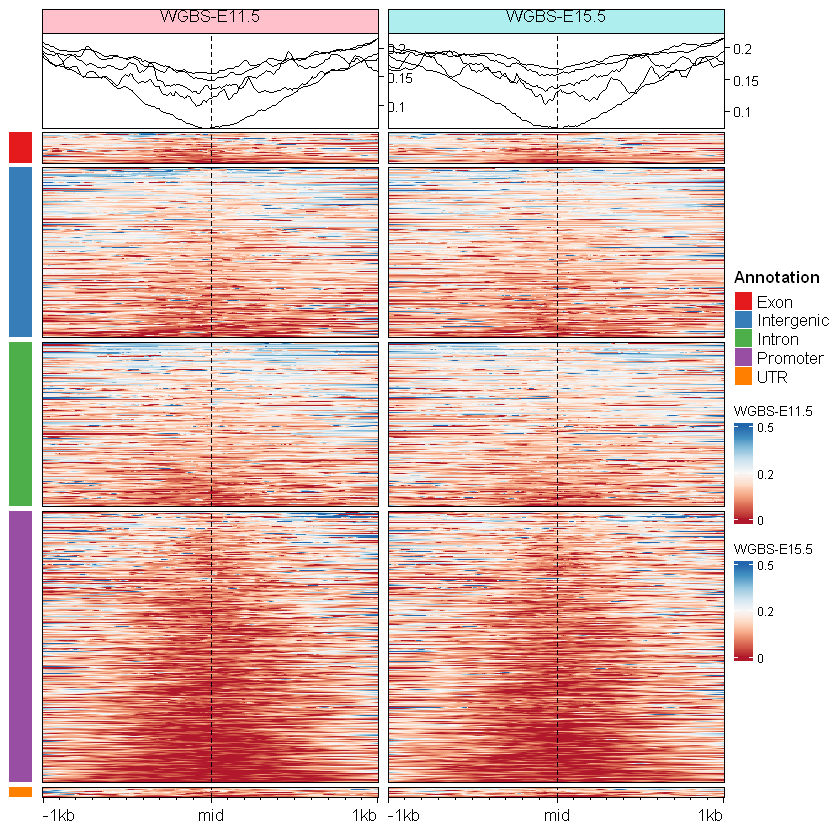

In [32]:
eh_wgbs_11h <- make_EH_custom_na(
  norm_mat = mat_bs[["WGBS_11half"]], 
  hm_name = 'WGBS-E11.5', 
  col_fill = 'pink')

eh_wgbs_15h <- make_EH_custom_na(
  norm_mat = mat_bs[["WGBS_15half"]], 
  hm_name = 'WGBS-E15.5', 
  col_fill = 'paleturquoise')

draw(
  eh_annotations + eh_wgbs_11h + eh_wgbs_15h, 
  split = split_anno)

### Biological interpretation of DNA methylation

Looking at our generated heatmaps, we can draw several immediate observational conclusions:

1. **No glaring global differences:** By naked eye, the global methylation profiles (Red = 0% unmethylated, Blue = 50% methylated) between E11.5 and E15.5 look virtually identical. There is no massive, genome-wide shift in methylation at these open chromatin regions between the two developmental stages.
2. **Promoters are unmethylated:** Thanks to our annotation splitting, we can clearly see that **Promoter** regions are intensely red (unmethylated). Furthermore, there is a distinct "dip" of unmethylated DNA exactly at the `mid` point of the ATAC peak. This makes perfect biological sense: active regulatory hubs must remain unmethylated to keep the DNA physically open for transcription factors.
3. **Introns and Intergenic regions are more methylated:** In contrast, the **Intron** and **Intergenic** blocks are noticeably more blue, indicating a higher level of basal methylation compared to the promoters.

While these visual **stratifications** provide fantastic biological context, we cannot definitively say if specific, individual peaks significantly gained or lost methylation between the two stages. To prove that mathematically, we would need to extract the raw `Me` and `Un` counts and run a heavy **statistical modeling** package (like `DSS` or `methylKit`) to generate formal `p-values` and `logFC` scores.